## Temporal Data Analysis for Workouts

In this notebook, we will perform the following temporal analyses on the processed workout data:

1. Identify impossible dates: Detect and handle dates like "31st April", "29th February" in non-leap years, or future dates.
2. Identify duplicate dates: Check if any workout entries are duplicated for the same date.
3. Identify inactivity periods: Find gaps where no workouts were recorded.
4. Analyze time trends: Analyze trends in the data over time (e.g., average pace by month/year).
5. Identify seasonal patterns: Explore any seasonal patterns in workout frequency or performance.
6. Make future predictions: Predict workout frequency or performance for the upcoming month.

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import os
os.chdir("C:/Users/Vale/Runalyze")

df = pd.read_csv("data/processed/processed_data.csv")
df.head(5)

,Workout ID,Date,Distance (km),Duration (min),Calories (kcal),Average Pace (min/km),Average Speed (km/h),Max Speed (km/h),Elevation Gain (m),Elevation Loss (m),Start Time,Temperature (C),Wind Speed (km/h),Humidity (%),Duration (sec),Average Pace (sec/km)
0,1,14/06/2023,4.37,20:00,316,04:35,13.1,18.1,13.0,13.0,19:11,22.0,11.0,80.0,1200,275
1,2,19/06/2023,4.45,20:00,315,04:29,13.3,15.5,12.0,13.0,20:06,29.0,14.0,53.0,1200,269
2,3,01/07/2023,5.26,25:01,395,04:45,12.6,15.1,12.0,14.0,12:09,22.0,8.0,79.0,1501,285
3,4,21/08/2023,4.03,20:02,312,04:58,12.1,14.3,0.0,10.0,19:03,34.0,8.0,42.0,1202,298
4,5,04/10/2023,3.76,20:01,305,05:19,11.3,13.6,9.0,13.0,17:03,25.0,13.0,68.0,1201,319


### Identify impossible dates

#### Future dates

In [119]:
# convert column 'Date' to pandas datetime object: invalid parsing will be set as NaT
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)

df.head(5)

,Workout ID,Date,Distance (km),Duration (min),Calories (kcal),Average Pace (min/km),Average Speed (km/h),Max Speed (km/h),Elevation Gain (m),Elevation Loss (m),Start Time,Temperature (C),Wind Speed (km/h),Humidity (%),Duration (sec),Average Pace (sec/km)
0,1,2023-06-14,4.37,20:00,316,04:35,13.1,18.1,13.0,13.0,19:11,22.0,11.0,80.0,1200,275
1,2,2023-06-19,4.45,20:00,315,04:29,13.3,15.5,12.0,13.0,20:06,29.0,14.0,53.0,1200,269
2,3,2023-07-01,5.26,25:01,395,04:45,12.6,15.1,12.0,14.0,12:09,22.0,8.0,79.0,1501,285
3,4,2023-08-21,4.03,20:02,312,04:58,12.1,14.3,0.0,10.0,19:03,34.0,8.0,42.0,1202,298
4,5,2023-10-04,3.76,20:01,305,05:19,11.3,13.6,9.0,13.0,17:03,25.0,13.0,68.0,1201,319


In [120]:
df.dtypes

Workout ID                        int64
Date                     datetime64[ns]
Distance (km)                   float64
Duration (min)                   object
Calories (kcal)                   int64
Average Pace (min/km)            object
Average Speed (km/h)            float64
Max Speed (km/h)                float64
Elevation Gain (m)              float64
Elevation Loss (m)              float64
Start Time                       object
Temperature (C)                 float64
Wind Speed (km/h)               float64
Humidity (%)                    float64
Duration (sec)                    int64
Average Pace (sec/km)             int64
dtype: object

In [121]:
from datetime import datetime

pd_today = pd.to_datetime(datetime.today(), format="%Y/%m/%d")
pd_today

Timestamp('2024-12-03 09:22:27.816136')

In [122]:
future_dates = df[df['Date'] > pd_today]

In [123]:
if not future_dates.empty:
    print(f"Found {len(future_dates)} future date(s).")
else:
    print("No future dates found.")

No future dates found.


#### Invalid dates (e.g., 30th February)

In [124]:
invalid_dates = df[df['Date'].isna()]

if not invalid_dates.empty:
    print(f"Found {len(invalid_dates)} invalid date(s).")
else:
    print("No invalid dates found.")

No invalid dates found.


### Identify Duplicate Dates

In [125]:
duplicated_dates = df[df.duplicated(subset=['Date'], keep=False)]
duplicated_dates_list = []

for idx, row in duplicated_dates.iterrows():
    if not row['Date'] in duplicated_dates_list:
        duplicated_dates_list.append(row['Date'])
        
print("You performed a repeat workout on the following dates: \n")
print("------------------------------------------------------\n")
for date in duplicated_dates_list:
    print(str(date).split(" ")[0] + '\n')

You performed a repeat workout on the following dates: 

------------------------------------------------------

2024-11-02

2024-11-23



### Identify Inactivity Periods

In [126]:
df = df.sort_values(by='Date')

In [127]:
df['Date Difference'] = df['Date'].diff().dt.days
df.head()

,Workout ID,Date,Distance (km),Duration (min),Calories (kcal),Average Pace (min/km),Average Speed (km/h),Max Speed (km/h),Elevation Gain (m),Elevation Loss (m),Start Time,Temperature (C),Wind Speed (km/h),Humidity (%),Duration (sec),Average Pace (sec/km),Date Difference
0,1,2023-06-14,4.37,20:00,316,04:35,13.1,18.1,13.0,13.0,19:11,22.0,11.0,80.0,1200,275,NaN
1,2,2023-06-19,4.45,20:00,315,04:29,13.3,15.5,12.0,13.0,20:06,29.0,14.0,53.0,1200,269,5.0
2,3,2023-07-01,5.26,25:01,395,04:45,12.6,15.1,12.0,14.0,12:09,22.0,8.0,79.0,1501,285,12.0
3,4,2023-08-21,4.03,20:02,312,04:58,12.1,14.3,0.0,10.0,19:03,34.0,8.0,42.0,1202,298,51.0
4,5,2023-10-04,3.76,20:01,305,05:19,11.3,13.6,9.0,13.0,17:03,25.0,13.0,68.0,1201,319,44.0


In [128]:
threshold = 7

inactivity_periods = df[df['Date Difference'] > threshold]
inactivity_periods

,Workout ID,Date,Distance (km),Duration (min),Calories (kcal),Average Pace (min/km),Average Speed (km/h),Max Speed (km/h),Elevation Gain (m),Elevation Loss (m),Start Time,Temperature (C),Wind Speed (km/h),Humidity (%),Duration (sec),Average Pace (sec/km),Date Difference
2,3,2023-07-01,5.26,25:01,395,04:45,12.6,15.1,12.0,14.0,12:09,22.0,8.0,79.0,1501,285,12.0
3,4,2023-08-21,4.03,20:02,312,04:58,12.1,14.3,0.0,10.0,19:03,34.0,8.0,42.0,1202,298,51.0
4,5,2023-10-04,3.76,20:01,305,05:19,11.3,13.6,9.0,13.0,17:03,25.0,13.0,68.0,1201,319,44.0
8,9,2023-11-01,3.00,15:02,237,05:00,12.0,14.4,12.0,9.0,14:48,14.0,8.0,96.0,902,300,13.0
9,10,2024-01-08,3.69,20:00,305,05:25,11.1,16.4,0.0,7.0,16:24,8.0,14.0,88.0,1200,325,68.0
19,20,2024-04-03,3.10,16:01,243,05:10,11.6,14.1,6.0,12.0,15:19,18.0,11.0,49.0,961,310,60.0
20,21,2024-08-10,5.02,23:13,366,04:37,13.0,14.6,5.0,18.0,08:30,26.0,6.0,67.0,1393,277,129.0
21,22,2024-09-15,1.68,06:02,91,03:35,16.7,21.0,0.0,10.0,11:09,19.0,11.0,49.0,362,215,36.0
30,31,2024-10-30,8.00,35:52,645,04:28,13.4,14.7,19.0,29.0,15.23,21.0,8.0,74.0,2152,268,13.0


In [129]:
inactivities = []

for idx, row in inactivity_periods.iterrows():
    current_id = row['Workout ID']
    
    previous_id = current_id - 1
    
    previous_wk = df[df["Workout ID"] == previous_id]
    
    start_date = previous_wk.iloc[0, 1].strftime('%Y-%m-%d')
    end_date = row['Date']
    duration = row['Date Difference']
    
    inactivities.append({
        'Start Date': start_date,
        'End Date': end_date,
        'Duration (days)': duration
    })
    
inactivity_df = pd.DataFrame(inactivities)
inactivity_df

,Start Date,End Date,Duration (days)
0,2023-06-19,2023-07-01,12.0
1,2023-07-01,2023-08-21,51.0
2,2023-08-21,2023-10-04,44.0
3,2023-10-19,2023-11-01,13.0
4,2023-11-01,2024-01-08,68.0
5,2024-02-03,2024-04-03,60.0
6,2024-04-03,2024-08-10,129.0
7,2024-08-10,2024-09-15,36.0
8,2024-10-17,2024-10-30,13.0


In [130]:
inactivity_df.dtypes

Start Date                 object
End Date           datetime64[ns]
Duration (days)           float64
dtype: object

In [131]:
inactivity_df['Start Date'] = pd.to_datetime(inactivity_df['Start Date'])
inactivity_df.dtypes

Start Date         datetime64[ns]
End Date           datetime64[ns]
Duration (days)           float64
dtype: object

Text(0, 0.5, 'Inactivty Periods')

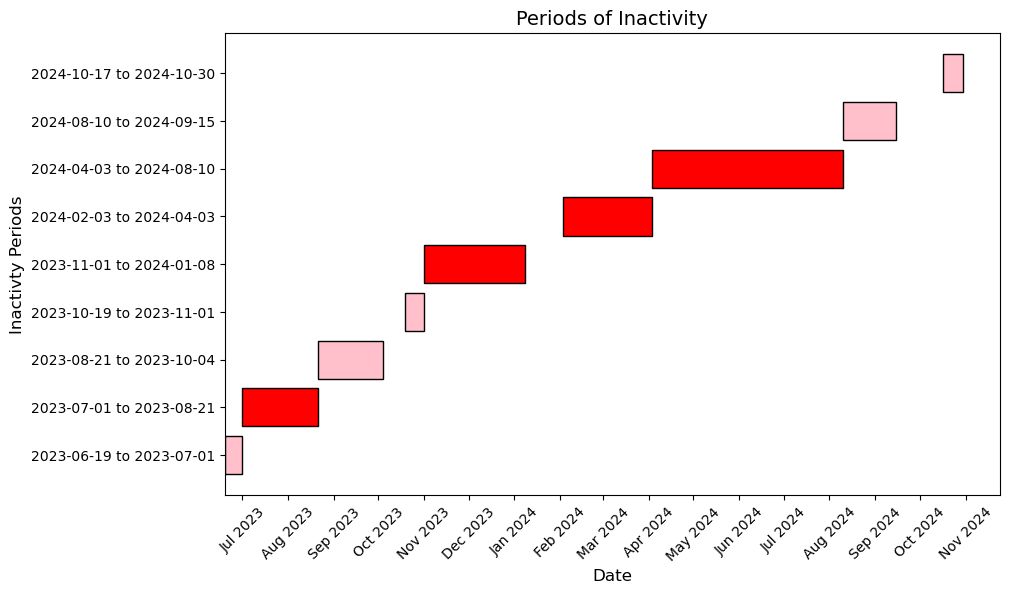

In [132]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10, 6))

for i, row in inactivity_df.iterrows():
    ax.barh(
        i, 
        row['Duration (days)'], 
        left=row['Start Date'], 
        color='red' if row['Duration (days)'] > 50 else 'pink', 
        edgecolor='black', 
        height=0.8
    )
    
ax.set_yticks(range(0, inactivity_df.index[-1]+1))
ax.set_yticklabels([f"{row['Start Date'].strftime('%Y-%m-%d')} to {row['End Date'].strftime('%Y-%m-%d')}"
                   for _, row in inactivity_df.iterrows()])

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)

ax.set_title('Periods of Inactivity', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Inactivty Periods', fontsize=12)

#### Monthly Workout Analysis

Analyzing the number of workouts per month and identifying inactive months.

In [149]:
df_without_duplicates = df.drop_duplicates(subset=['Date'], keep='first')

monthly_wks = df_without_duplicates.groupby(df_without_duplicates['Date'].dt.to_period('M')).size()
monthly_wks

Date
2023-06    2
2023-07    1
2023-08    1
2023-10    4
2023-11    1
2024-01    9
2024-02    1
2024-04    1
2024-08    1
2024-09    5
2024-10    5
2024-11    8
Freq: M, dtype: int64

In [161]:
start_date = (df_without_duplicates.iloc[0].Date).strftime('%Y-%m')
end_date = (df_without_duplicates.iloc[-1].Date).strftime('%Y-%m')

time_interval = f"{start_date} --> {end_date}"
print(time_interval)

2023-06 --> 2024-11


In [169]:
all_months = pd.date_range(start=start_date, end=end_date, freq='MS').to_period('M')

missing_months = all_months[~all_months.isin(monthly_wks.index)]
missing_months

PeriodIndex(['2023-09', '2023-12', '2024-03', '2024-05', '2024-06', '2024-07'], dtype='period[M]')

In [174]:
inactive_month_dict = {month: 0 for month in missing_months}

inactive_month_series = pd.Series(inactive_month_dict)
inactive_month_series

2023-09    0
2023-12    0
2024-03    0
2024-05    0
2024-06    0
2024-07    0
Freq: M, dtype: int64

In [179]:
wks_per_month = pd.concat([monthly_wks, inactive_month_series])
wks_per_month = wks_per_month.sort_index()
wks_per_month

2023-06    2
2023-07    1
2023-08    1
2023-09    0
2023-10    4
2023-11    1
2023-12    0
2024-01    9
2024-02    1
2024-03    0
2024-04    1
2024-05    0
2024-06    0
2024-07    0
2024-08    1
2024-09    5
2024-10    5
2024-11    8
Freq: M, dtype: int64

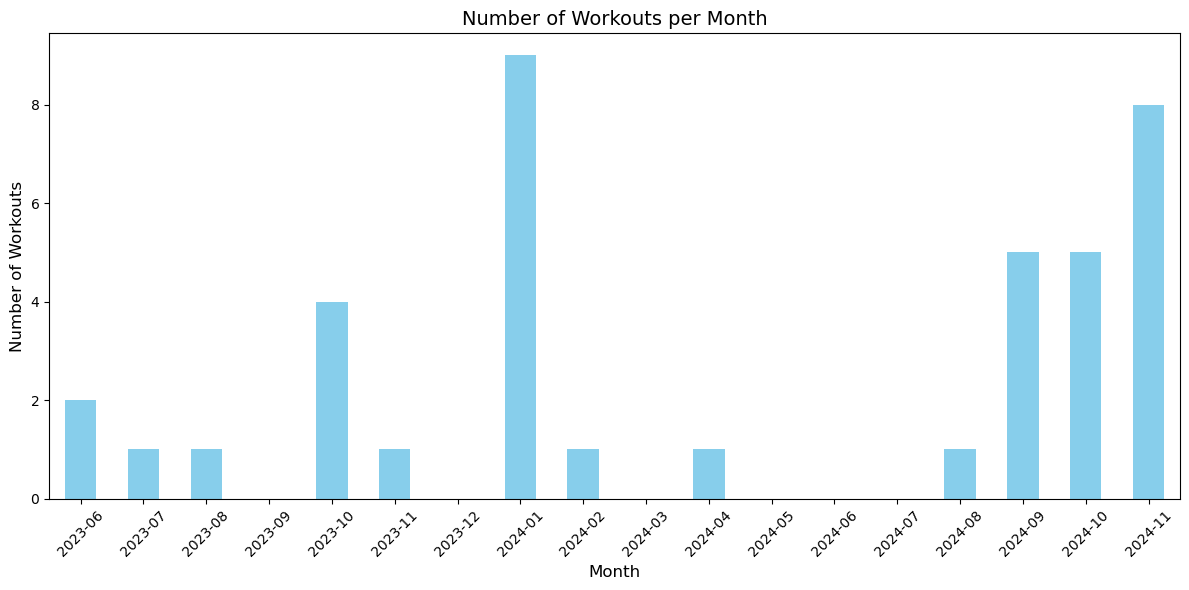

In [181]:
plt.figure(figsize=(12, 6))
wks_per_month.plot(kind='bar', color='skyblue')

plt.title('Number of Workouts per Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Workouts', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

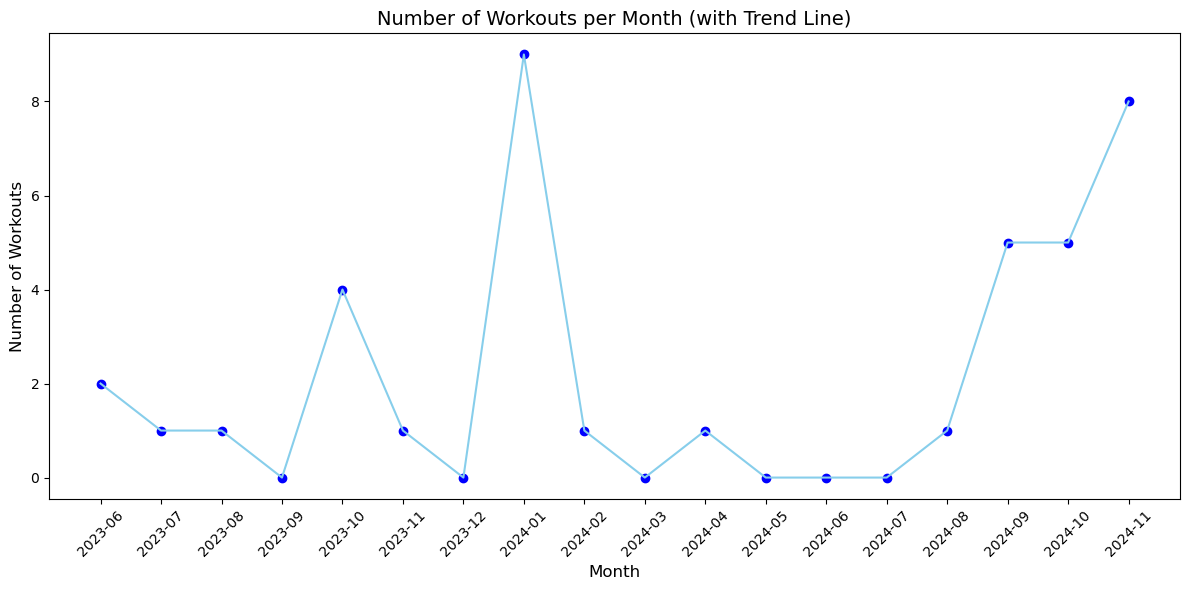

In [192]:
plt.figure(figsize=(12,6))

plt.scatter(wks_per_month.index.astype(str), wks_per_month.values, color='blue')
plt.plot(wks_per_month.index.astype(str), wks_per_month.values, color='skyblue')

plt.title('Number of Workouts per Month (with Trend Line)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Workouts', fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()